In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'E:\Credit Risk Project\accepted_2007_to_2018q4.csv\accepted_2007_to_2018q4.csv', nrows=50)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
for col in df.columns:
    print(col)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [4]:
df['policy_code'].value_counts()

policy_code
1.0    50
Name: count, dtype: int64

In [5]:
cols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade',
    'emp_length', 'home_ownership', 'annual_inc', 'loan_status',
    'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'purpose'
]

df = df[cols]
df.shape
    

(50, 19)

In [6]:
df = pd.read_csv(r'E:\Credit Risk Project\accepted_2007_to_2018q4.csv\accepted_2007_to_2018q4.csv', usecols = cols)
df.shape

(2260701, 19)

In [7]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [8]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df.shape

(1345310, 19)

In [9]:
df['loan_status'].value_counts()

loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

In [10]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
Fully Paid     80.037389
Charged Off    19.962611
Name: proportion, dtype: float64

In [11]:
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

In [12]:
df['loan_status'].value_counts()

loan_status
0    1076751
1     268559
Name: count, dtype: int64

In [13]:
df.isnull().sum()

loan_amnt              0
term                   0
int_rate               0
installment            0
grade                  0
emp_length         78511
home_ownership         0
annual_inc             0
loan_status            0
purpose                0
dti                  374
delinq_2yrs            0
fico_range_low         0
fico_range_high        0
open_acc               0
pub_rec                0
revol_bal              0
revol_util           857
total_acc              0
dtype: int64

In [14]:
df['emp_length'] = df['emp_length'].fillna('Unknown')
df['dti'] = df['dti'].fillna(df['dti'].median()) 
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

In [15]:
df.isnull().sum()

loan_amnt          0
term               0
int_rate           0
installment        0
grade              0
emp_length         0
home_ownership     0
annual_inc         0
loan_status        0
purpose            0
dti                0
delinq_2yrs        0
fico_range_low     0
fico_range_high    0
open_acc           0
pub_rec            0
revol_bal          0
revol_util         0
total_acc          0
dtype: int64

In [16]:
df.dtypes

loan_amnt          float64
term                object
int_rate           float64
installment        float64
grade               object
emp_length          object
home_ownership      object
annual_inc         float64
loan_status          int64
purpose             object
dti                float64
delinq_2yrs        float64
fico_range_low     float64
fico_range_high    float64
open_acc           float64
pub_rec            float64
revol_bal          float64
revol_util         float64
total_acc          float64
dtype: object

In [17]:
df['term'].value_counts()

term
36 months    1020743
60 months     324567
Name: count, dtype: int64

In [18]:
df['term'] = df['term'].str.replace('months', "")

In [19]:
df['term'].value_counts()

term
36     1020743
60      324567
Name: count, dtype: int64

In [20]:
df['term'] = df['term'].astype(int)

In [21]:
df['term'].value_counts()

term
36    1020743
60     324567
Name: count, dtype: int64

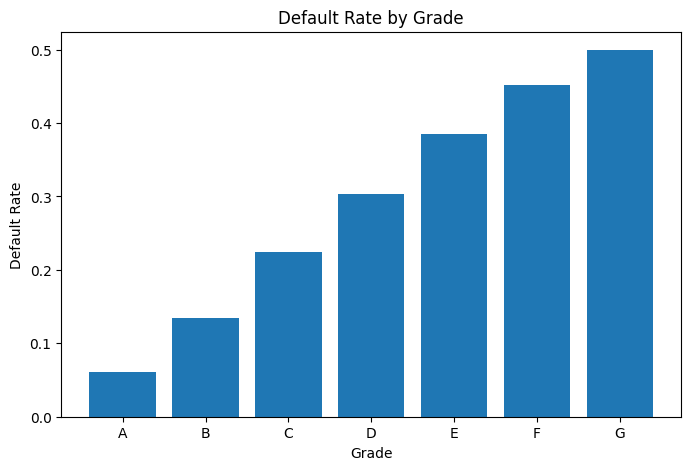

In [22]:
default_by_grade = df.groupby('grade')['loan_status'].mean()

plt.figure(figsize=(8, 5))
plt.bar(default_by_grade.index, default_by_grade.values)
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.title('Default Rate by Grade')
plt.show()

C:\Users\Aan Noor Rahman\AppData\Local\Temp\ipykernel_9840\1915308686.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_dti = df.groupby('dti_bucket')['loan_status'].mean()


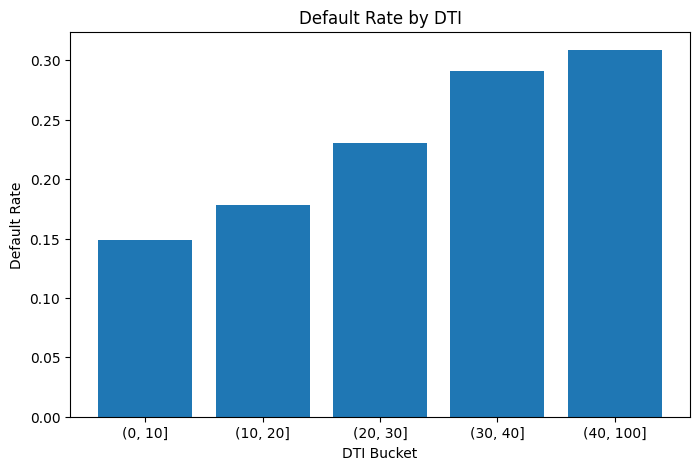

In [23]:
df['dti_bucket'] = pd.cut(df['dti'], bins=[0, 10, 20, 30, 40, 100])

default_by_dti = df.groupby('dti_bucket')['loan_status'].mean()

plt.figure(figsize=(8, 5))
plt.bar(default_by_dti.index.astype(str), default_by_dti.values)
plt.xlabel('DTI Bucket')
plt.ylabel('Default Rate')
plt.title('Default Rate by DTI')
plt.show()

C:\Users\Aan Noor Rahman\AppData\Local\Temp\ipykernel_9840\13246262.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_fico = df.groupby('fico_bucket')['loan_status'].mean()


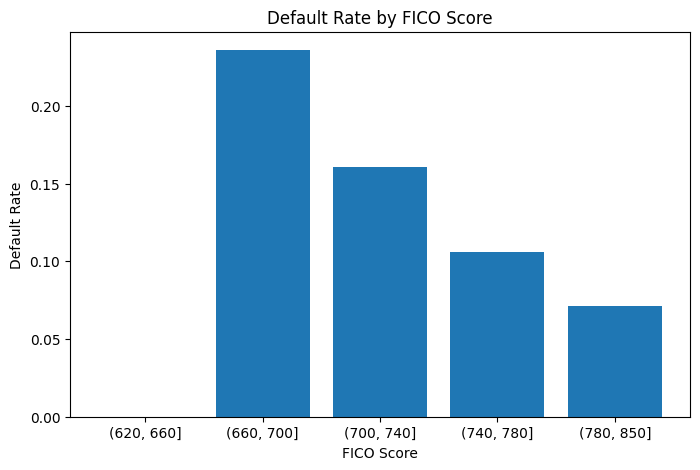

In [24]:
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2

df['fico_bucket'] = pd.cut(df['fico_score'], bins=[580, 620, 660, 700, 740, 780, 850])

default_by_fico = df.groupby('fico_bucket')['loan_status'].mean()

plt.figure(figsize=(8, 5))
plt.bar(default_by_fico.index.astype(str), default_by_fico.values)
plt.xlabel('FICO Score')
plt.ylabel('Default Rate')
plt.title('Default Rate by FICO Score')
plt.show()

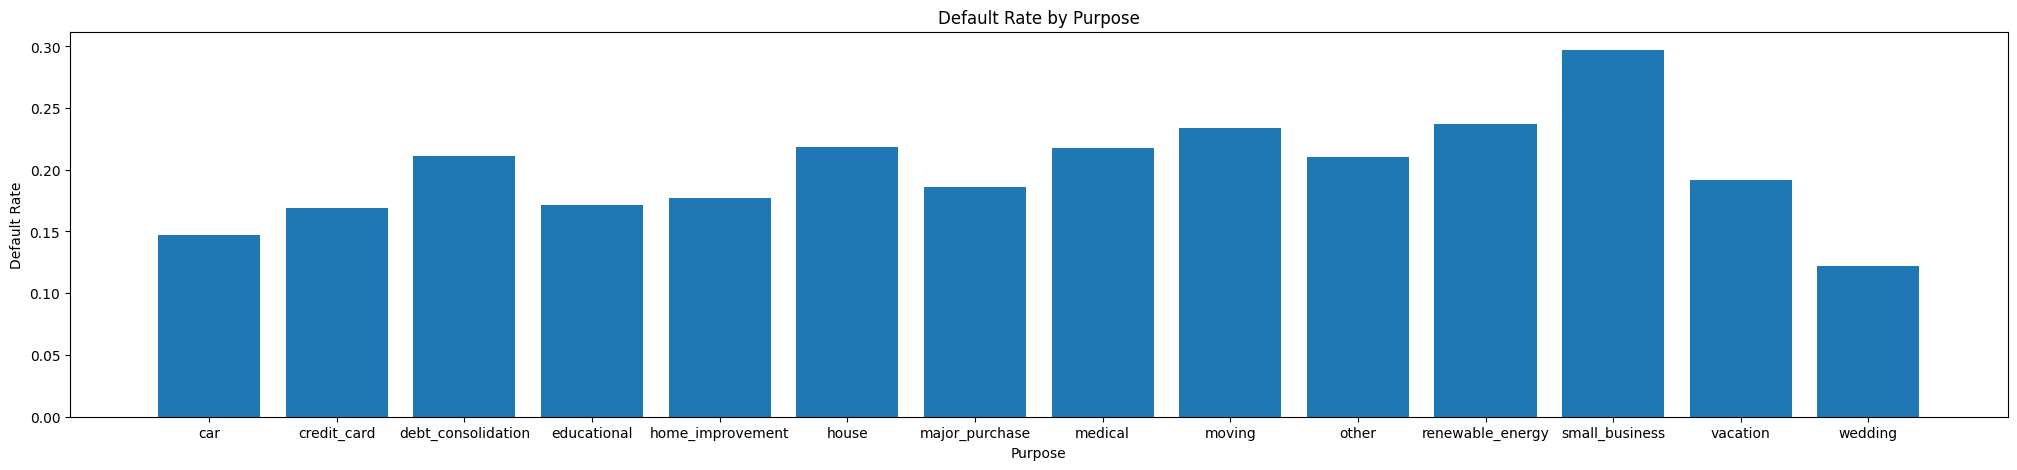

In [25]:
default_by_purpose = df.groupby('purpose')['loan_status'].mean()

plt.figure(figsize=(25, 5))
plt.bar(default_by_purpose.index, default_by_purpose.values)
plt.xlabel('Purpose')
plt.ylabel('Default Rate')
plt.title('Default Rate by Purpose')
plt.show()

In [26]:
df['emp_length'].value_counts()

emp_length
10+ years    442199
2 years      121743
< 1 year     108061
3 years      107597
1 year        88494
5 years       84154
4 years       80556
Unknown       78511
6 years       62733
8 years       60701
7 years       59624
9 years       50937
Name: count, dtype: int64

In [27]:
emp_length_order = {
    'Unknown': 0,
    '< 1 year': 1,
    '1 year': 2,
    '2 years': 3,
    '3 years': 4,
    '4 years': 5,
    '5 years': 6,
    '6 years': 7,
    '7 years': 8,
    '8 years': 9,
    '9 years': 10,
    '10+ years': 11
}

In [28]:
df['emp_length'] = df['emp_length'].map(emp_length_order)

In [29]:
df['emp_length'].value_counts()

emp_length
11    442199
3     121743
1     108061
4     107597
2      88494
6      84154
5      80556
0      78511
7      62733
9      60701
8      59624
10     50937
Name: count, dtype: int64

In [30]:
df['purpose'].unique()

array(['debt_consolidation', 'small_business', 'home_improvement',
       'major_purchase', 'credit_card', 'other', 'house', 'vacation',
       'car', 'medical', 'moving', 'renewable_energy', 'wedding',
       'educational'], dtype=object)

In [31]:
df = pd.get_dummies(df, columns=['grade', 'home_ownership', 'purpose'], drop_first=True)
df = df.drop(columns=['dti_bucket', 'fico_score', 'fico_bucket'])
df.shape

(1345310, 40)

## Model Training 

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

x = df.drop(columns=['loan_status'])
y = df['loan_status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:,1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.89      0.63      0.74    215608
           1       0.31      0.67      0.43     53454

    accuracy                           0.64    269062
   macro avg       0.60      0.65      0.58    269062
weighted avg       0.77      0.64      0.68    269062

ROC-AUC: 0.7087260558312038


In [48]:
import sqlite3

results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'default_probability': y_prob
})

In [49]:
results.head()

,actual,predicted,default_probability
1209559,0,0,0.201418
896438,0,1,0.586842
1183073,0,1,0.614675
61710,0,0,0.399357
686251,0,0,0.389144


In [51]:
results['risk_band'] = pd.cut(
    results['default_probability'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

In [52]:
results['risk_band'].value_counts()

risk_band
Medium       101222
Low           77547
High          59781
Very Low      24905
Very High      5607
Name: count, dtype: int64

In [54]:
conn = sqlite3.connect('credit_risk.db')
results.to_sql('loan_predictions', conn, if_exists='replace', index=True)
print('saved')

saved


In [56]:
query = """
SELECT risk_band, AVG(actual)
FROM loan_predictions
GROUP BY risk_band
"""
pd.read_sql(query, conn)

,risk_band,AVG(actual)
0,High,0.353540
1,Low,0.101293
2,Medium,0.201103
3,Very High,0.548600
4,Very Low,0.041437


In [60]:
query = """
SELECT risk_band, AVG(default_probability)
FROM loan_predictions
GROUP BY  risk_band
"""
pd.read_sql(query,conn)

,risk_band,AVG(default_probability)
0,High,0.682094
1,Low,0.309539
2,Medium,0.498850
3,Very High,0.831840
4,Very Low,0.157563


In [63]:
query = """
SELECT risk_band, COUNT(*) AS false_positive
FROM loan_predictions
WHERE actual = 1 AND predicted = 0
GROUP BY risk_band
"""
pd.read_sql(query, conn)

,risk_band,false_positive
0,Low,7855
1,Medium,8705
2,Very Low,1032


In [62]:
conn.close

<function Connection.close()>

In [65]:
import numpy as np

factor = 20 / np.log(2)
offset = 600 - factor *np.log(50)

results['score'] = offset + factor * np.log((1 - results['default_probability']) / results['default_probability'])
results['score'] = results['score'].clip(300, 850).round()

results[['actual', 'default_probability', 'risk_band', 'score']].head(10)

,actual,default_probability,risk_band,score
1209559,0,0.201418,Low,587.0
896438,0,0.586842,Medium,578.0
1183073,0,0.614675,High,578.0
61710,0,0.399357,Low,582.0
686251,0,0.389144,Low,582.0
234204,0,0.219675,Low,586.0
660620,1,0.407473,Medium,582.0
254441,0,0.477717,Medium,580.0
1637290,0,0.227318,Low,586.0
80315,0,0.428270,Medium,581.0


In [67]:
results.groupby('risk_band')['score'].mean().round()

C:\Users\Aan Noor Rahman\AppData\Local\Temp\ipykernel_9840\3805292718.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby('risk_band')['score'].mean().round()


risk_band
Very Low     589.0
Low          584.0
Medium       580.0
High         576.0
Very High    572.0
Name: score, dtype: float64